# Calcium Aluminosilicate Glass Simulation with SHIK Potential
This notebook is designed to showcase the implementations of the amorphouspy package for simulating multi-component glasses with classical interatomic potentials.

## Potential and Elements
Simulations implemented so far are based on the SHIK interatomic potential from S. Sundararaman et al., 
- for silica glass, J. Chem. Phys. 2018, 148, 19, https://doi.org/10.1063/1.5023707
- for alkali and alkaline-earth aluminosilicate glasses, J. Chem. Phys. 2019, 150, 15, https://doi.org/10.1063/1.5079663
- for borate glasses with mixed network formers, J. Chem. Phys. 2020, 152, 10, https://doi.org/10.1063/1.5142605
- for alkaline earth silicate and borate glasses, Shih et al. J. Non-Cryst. Sol. 2021, 565, 120853, https://doi.org/10.1016/j.jnoncrysol.2021.120853

The SHIK potential makes use of 2-body Buckingham interactions between oxygen and cations, electrostatic interactions based on partial charges among all ions and oxygen charge is composition dependent, and a repulsive short-range term.

The supported elements in alphabetical order are:

Li, Na, K, Mg, Ca, B, Al, Si, O

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Mixed network formers: SiO2-B2O3-Al2O3 systems

## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [1]:
from executorlib import SingleNodeExecutor


from amorphouspy import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

# Example Melt-Quenching Simulation

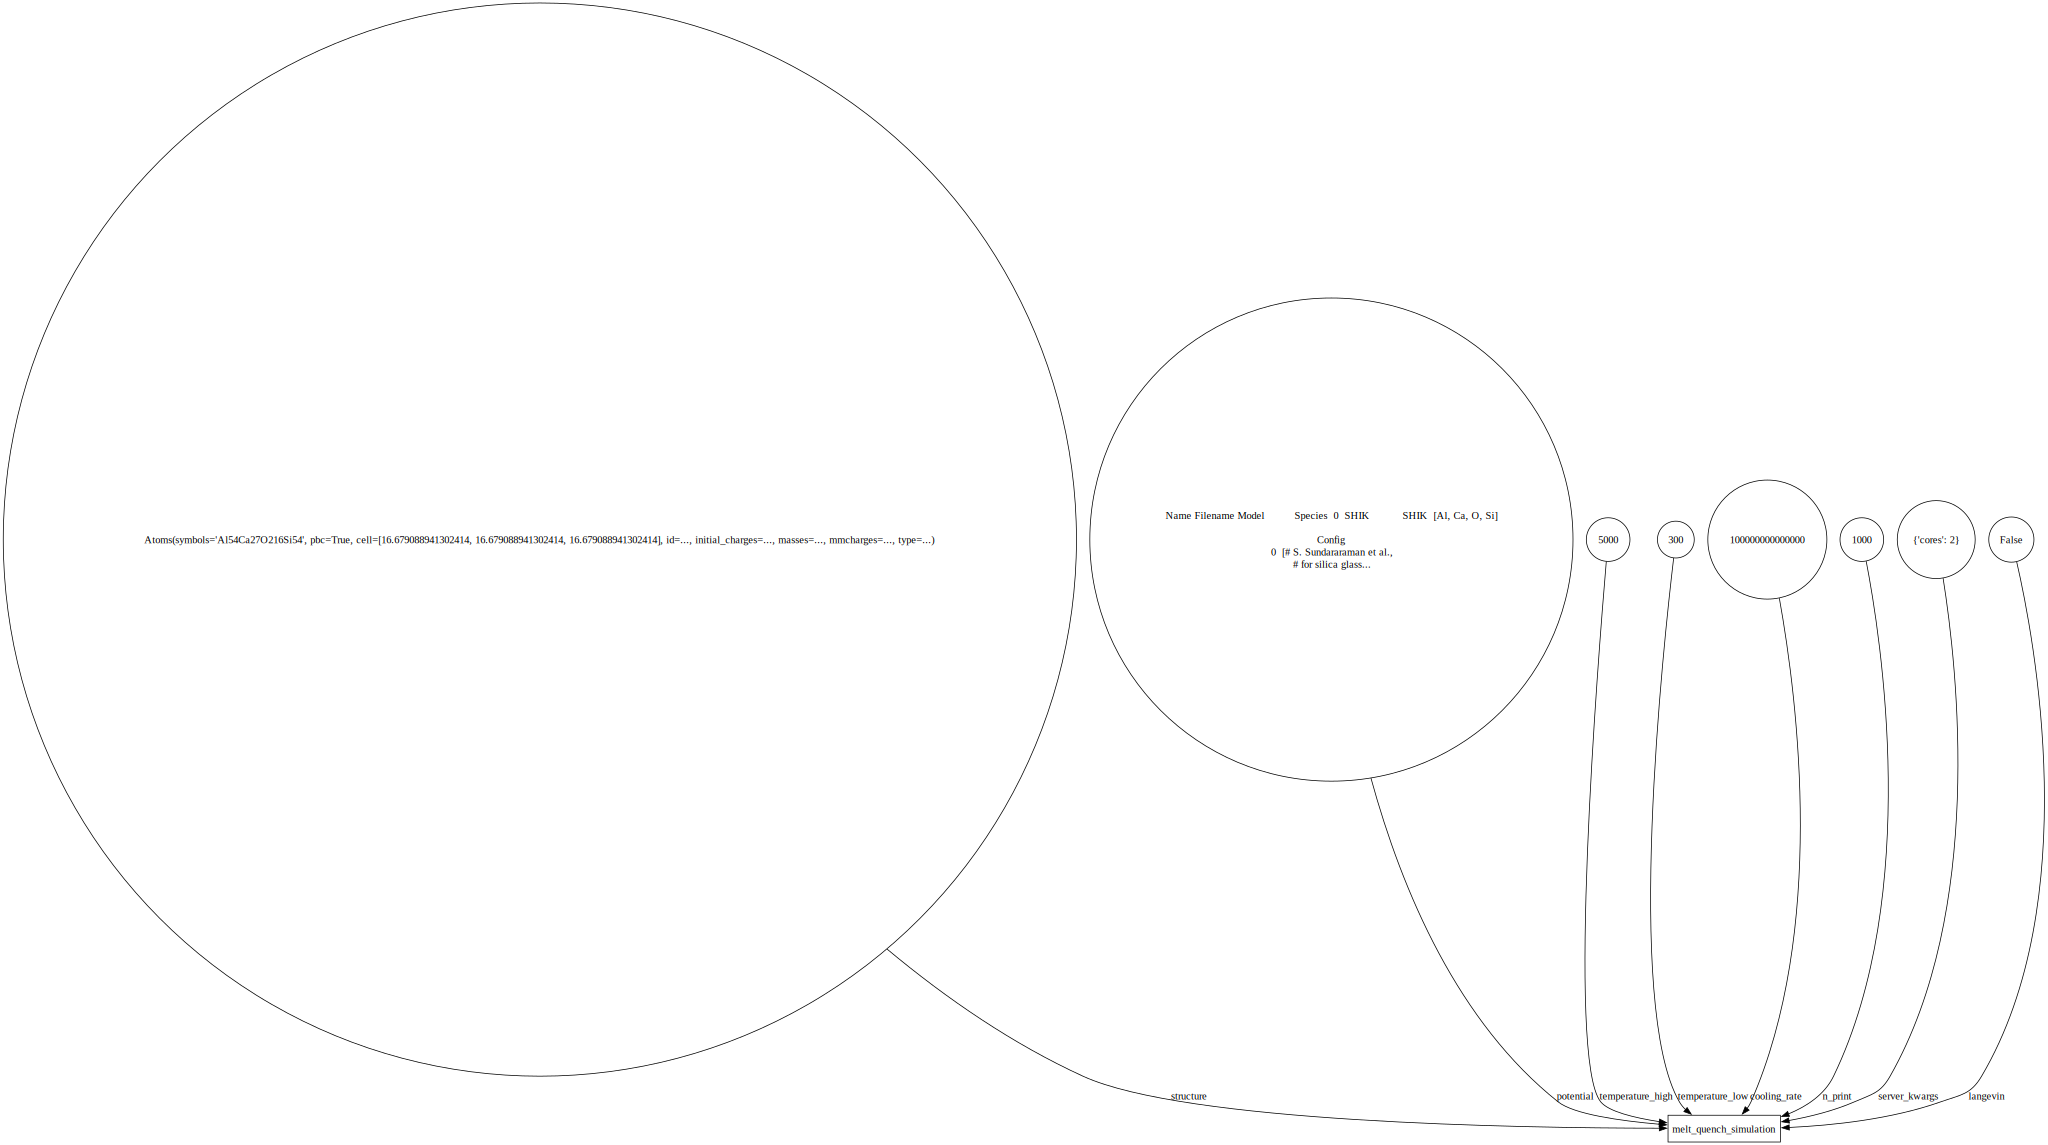

In [2]:
# Project setup,
# generating an initial random structure
# and setting up the potential information
with SingleNodeExecutor(plot_dependency_graph=True) as exe:
    atoms_dict_future = get_structure_dict(
        composition="25CaO-25Al2O3-50SiO2",  #    comp = "20.2CaO-36.6Al2O3-43.2SiO2" this is in weight%,
        n_molecules=None,
        target_atoms=350,
        mode="molar",  # mode = "weight",
        density=None,
        min_distance=2.0,
        max_attempts_per_atom=10000,
    )
    structure_future = get_ase_structure(
        atoms_dict=atoms_dict_future,
        replicate=(1, 1, 1),
    )
    generated_potential_future = generate_potential(
        atoms_dict=atoms_dict_future,
        potential_type="shik",
    )
    # Specification of the cpu parameters
    ncpus = 2
    server_kwargs = {"cores": ncpus}

    # Specification of the melt-quenching parameters
    delayed = exe.submit(
        melt_quench_simulation,
        structure=structure_future,
        potential=generated_potential_future,
        temperature_high=5000,
        temperature_low=300,
        n_print=1000,
        heating_rate=int(1e14),
        cooling_rate=int(1e14),
        langevin=False,
        server_kwargs=server_kwargs,
    )
    result = delayed.result()

In [3]:
# structure_glass = result["structure"]
# structure_glass

In [4]:
# Compute teh mean temperature of the last part of the simulation
# mean_temp = np.mean(result["result"]["temperature"])
# print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
# plt.plot(result["result"]["steps"] * 1e-3, result["result"]["temperature"])
# plt.axhline(np.mean(result["result"]["temperature"]), color="red", linestyle="--")
# plt.xlabel("Time [ps]")
# plt.ylabel("Temperature [K]");

In [5]:
#  from ase import units

# "# NBVAL_CHECK_OUTPUT"


#  V = np.mean(result["result"]["volume"]) * 1e-24  # volume in cm#
#  massTot = result["structure"].get_masses().sum() / units._Nav

#  density = massTot / V
#  print(f"{(massTot / V):.2f} g/cm3")